Propagazione SSO in corso per 30 giorni...

  EVOLUZIONE DELLA RAAN IN ORBITA SSO
RAAN iniziale (t=0):       0.000 deg
RAAN dopo 24 ore (t=1d):   0.990 deg  (+ ~1 deg)
RAAN dopo 30 giorni (t=30d): 29.630 deg  (+ ~30 deg)

Generazione grafico 3D in corso...


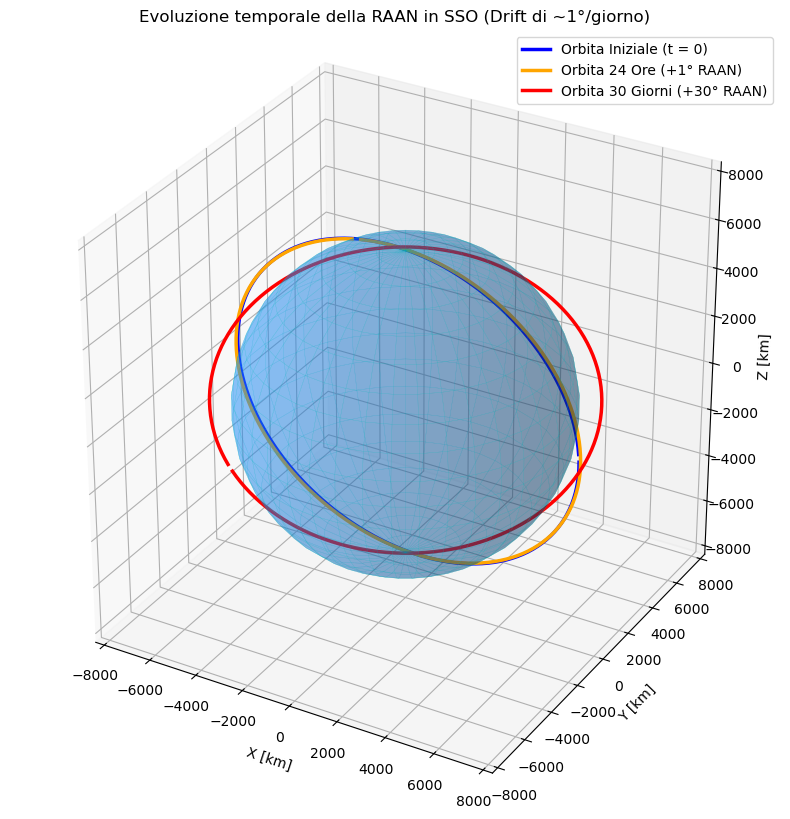

In [2]:
import math
import numpy as np
import matplotlib.pyplot as plt
import orekit
from orekit.pyhelpers import setup_orekit_curdir
from orekit import JArray_double

# ==========================================
# 1. INIZIALIZZAZIONE AMBIENTE OREKIT
# ==========================================
orekit.initVM()
setup_orekit_curdir('C:/Users/Simone/Downloads/orekit-data-main')

from org.orekit.orbits import KeplerianOrbit, PositionAngleType
from org.orekit.frames import FramesFactory
from org.orekit.time import TimeScalesFactory, AbsoluteDate
from org.orekit.utils import Constants, IERSConventions
from org.orekit.propagation.numerical import NumericalPropagator
from org.hipparchus.ode.nonstiff import DormandPrince853Integrator
from org.orekit.propagation import SpacecraftState
from org.orekit.forces.gravity.potential import GravityFieldFactory
from org.orekit.forces.gravity import HolmesFeatherstoneAttractionModel

# ==========================================
# 2. DEFINIZIONE DEL TEMPO E DEI FRAME
# ==========================================
utc = TimeScalesFactory.getUTC()
initial_date = AbsoluteDate(2026, 8, 4, 12, 0, 0.0, utc)

inertial_frame = FramesFactory.getEME2000()
earth_frame = FramesFactory.getITRF(IERSConventions.IERS_2010, True)
mu = Constants.WGS84_EARTH_MU

# ==========================================
# 3. CREAZIONE DELL'ORBITA (SSO a 800 km)
# ==========================================
a = Constants.WGS84_EARTH_EQUATORIAL_RADIUS + 800e3  # 800 km
e = 0.001
i = math.radians(98.6)  # Inclinazione SSO
omega = math.radians(0.0)
raan = math.radians(0.0)
lM = math.radians(0.0)

initial_orbit = KeplerianOrbit(a, e, i, omega, raan, lM, PositionAngleType.MEAN, inertial_frame, initial_date, mu)
initial_state = SpacecraftState(initial_orbit, 850.0)

# ==========================================
# 4. CONFIGURAZIONE DEL PROPAGATORE
# ==========================================
min_step = 0.001
max_step = 300.0
position_tolerance = 10.0 
tolerances = NumericalPropagator.tolerances(position_tolerance, initial_orbit, initial_orbit.getType())
abs_tolerance = JArray_double.cast_(tolerances[0])
rel_tolerance = JArray_double.cast_(tolerances[1])

integrator = DormandPrince853Integrator(min_step, max_step, abs_tolerance, rel_tolerance)
propagator = NumericalPropagator(integrator)
propagator.setInitialState(initial_state)

ephemeris_generator = propagator.getEphemerisGenerator()

# Aggiungiamo il campo gravitazionale per l'effetto J2
gravity_provider = GravityFieldFactory.getNormalizedProvider(4, 4)
propagator.addForceModel(HolmesFeatherstoneAttractionModel(earth_frame, gravity_provider))

# ==========================================
# 5. PROPAGAZIONE (30 GIORNI)
# ==========================================
giorni = 30.0
duration = giorni * 24.0 * 3600.0  
final_date = initial_date.shiftedBy(duration)

print(f"Propagazione SSO in corso per {int(giorni)} giorni...")
final_state = propagator.propagate(final_date)

# Recuperiamo l'orbita a 24 ore usando l'effemeride
ephemeris = ephemeris_generator.getGeneratedEphemeris()
state_24h = ephemeris.propagate(initial_date.shiftedBy(24.0 * 3600.0))

orbit_24h = KeplerianOrbit(state_24h.getOrbit())
orbit_30d = KeplerianOrbit(final_state.getOrbit())

# ==========================================
# 6. RISULTATI (Confronto RAAN)
# ==========================================
raan_24h = math.degrees(orbit_24h.getRightAscensionOfAscendingNode())
raan_30d = math.degrees(orbit_30d.getRightAscensionOfAscendingNode())

print("\n========================================================")
print("  EVOLUZIONE DELLA RAAN IN ORBITA SSO")
print("========================================================")
print(f"RAAN iniziale (t=0):       {math.degrees(raan):.3f} deg")
print(f"RAAN dopo 24 ore (t=1d):   {raan_24h:.3f} deg  (+ ~1 deg)")
print(f"RAAN dopo {int(giorni)} giorni (t=30d): {raan_30d:.3f} deg  (+ ~30 deg)")
print("========================================================\n")

# ==========================================
# 7. VISUALIZZAZIONE 3D (3 FOTOGRAFIE NEL TEMPO)
# ==========================================
print("Generazione grafico 3D in corso...")
periodo_orbitale = 6000.0  # L'orbita a 800 km dura circa 100 minuti

# Funzione per estrarre 1 orbita in un dato istante
def estrai_orbita(start_time, end_time):
    times = np.linspace(start_time, end_time, 150)
    x, y, z = [], [], []
    for t in times:
        current_date = initial_date.shiftedBy(float(t))
        pos = ephemeris.propagate(current_date).getPVCoordinates().getPosition()
        x.append(pos.getX() / 1000.0)
        y.append(pos.getY() / 1000.0)
        z.append(pos.getZ() / 1000.0)
    return x, y, z

# Estraiamo i 3 giri
x0, y0, z0 = estrai_orbita(0, periodo_orbitale)                                  # Giro Iniziale
x1, y1, z1 = estrai_orbita(86400, 86400 + periodo_orbitale)                      # Dopo 1 giorno
x30, y30, z30 = estrai_orbita(duration - periodo_orbitale, duration)             # Dopo 30 giorni

fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, projection='3d')

# Disegniamo la Terra
u, v = np.mgrid[0:2*np.pi:40j, 0:np.pi:20j]
R_E_km = Constants.WGS84_EARTH_EQUATORIAL_RADIUS / 1000.0
x_earth = R_E_km * np.cos(u) * np.sin(v)
y_earth = R_E_km * np.sin(u) * np.sin(v)
z_earth = R_E_km * np.cos(v)
ax.plot_surface(x_earth, y_earth, z_earth, color='dodgerblue', alpha=0.3, edgecolor='c', linewidth=0.2)

# Plot delle 3 orbite
ax.plot(x0, y0, z0, color='blue', linewidth=2.5, label='Orbita Iniziale (t = 0)')
ax.plot(x1, y1, z1, color='orange', linewidth=2.5, label='Orbita 24 Ore (+1° RAAN)')
ax.plot(x30, y30, z30, color='red', linewidth=2.5, label='Orbita 30 Giorni (+30° RAAN)')

lim = R_E_km + 2000
ax.set_xlim([-lim, lim]); ax.set_ylim([-lim, lim]); ax.set_zlim([-lim, lim])
ax.set_box_aspect([1,1,1]) 

ax.set_xlabel('X [km]'); ax.set_ylabel('Y [km]'); ax.set_zlabel('Z [km]')
ax.set_title('Evoluzione temporale della RAAN in SSO (Drift di ~1°/giorno)')
ax.legend(loc='upper right')

plt.show()